<a href="https://colab.research.google.com/github/sid-sank/Computational-Statistics/blob/main/Class_08_logistic_regression_and_kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic regression

In [62]:
# Import necessary packages
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import *
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.pipeline import Pipeline

In [2]:
iris = load_iris()
X = iris.data[:, :4]
y = iris.target
type(X)
print(iris)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

Perform Logisitic Regression and kNN on this dataset following the below steps:

1.  Preprocess the data
    * Check for empty values or nulls and perform necessary imputations/deletions
    * Encode the class variable numerically using the label encoder
    * Scale features as necessary
2. Logistic regression
    * Create a logistic regression model
    * Fit the logistic regression model to the train data
    * Get predictions for the class variable (y)
    * Get the train accuracy and test accuracy. Here accuracy is basically the fraction of correctly classified samples, i.e., y_pred==y_true.
3. Plotting the decision boundaries for Logistic Regression
    * Create scatter plots taking any two features at a time
    * Plot the decision boundary using sklearn's DecisionBoundaryDisplay
4. kNN
    * Create a kNN model
    * Fit the kNN to the train data
    * Get predictions for the class variable (y)
    * Get the train accuracy and test accuracy. Here accuracy is basically the fraction of correctly classified samples, i.e., y_pred==y_true.
5. Plotting the decision boundaries for Logistic Regression
    * Create scatter plots taking any two features at a time
    * Plot the decision boundary using sklearn's DecisionBoundaryDisplay

In [ ]:
print(y)
print(X)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 

In [3]:
enc = LabelEncoder()
y_encoded = enc.fit_transform(y)
print(y_encoded)
print(y)


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(150, 4)

### Create Logistic Regression

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size= 0.3, random_state= 42)
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [9]:
model.score(X_train, y_train)

0.9619047619047619

In [45]:
print(model.coef_)

[[-0.98038903  1.0514275  -1.74778303 -1.60432635]
 [ 0.48807594 -0.36335348 -0.29971165 -0.67617406]
 [ 0.49231309 -0.68807402  2.04749468  2.28050042]]


In [10]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
print(accuracy_score(y_train, y_pred_train))
print(accuracy_score(y_test, y_pred_test))

0.9619047619047619
1.0


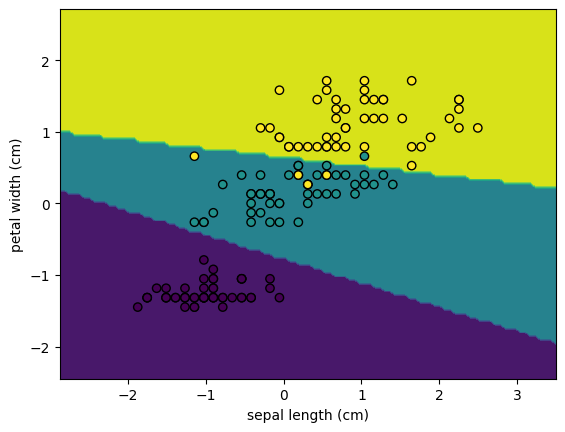

In [70]:
a,b = 0,3
visual_model = LogisticRegression().fit(X_scaled[:, [a,b]], y_encoded)

display = DecisionBoundaryDisplay.from_estimator(visual_model,
                                                 X_scaled[:, [a, b]],
                                                 xlabel=iris.feature_names[a],
                                                 ylabel=iris.feature_names[b])
display.ax_.scatter(X_scaled[:, a], X_scaled[:, b], c=y_encoded, edgecolors='k')

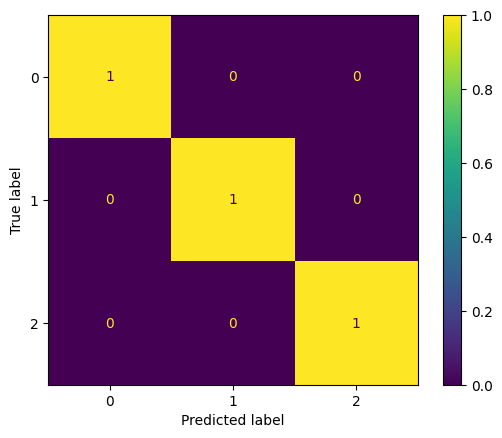

In [27]:
conf_mat = confusion_matrix(y_true= y_test, y_pred= y_pred_test, normalize= "true")

disp = ConfusionMatrixDisplay(conf_mat)
disp.plot()
plt.show()

In [41]:
f1_score(y_test, y_pred_test, average="macro")

1.0

In [44]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [47]:
poly = PolynomialFeatures(degree= 2)
X_poly = poly.fit_transform(X)
X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(X_poly, y, test_size=0.3, random_state=42)
poly_model = LogisticRegression()
poly_model.fit(X_poly_train, y_poly_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [49]:
y_poly_pred_train = poly_model.predict(X_poly_train)
y_poly_pred_test = poly_model.predict(X_poly_test)
print(accuracy_score(y_poly_train, y_poly_pred_train))
print(accuracy_score(y_poly_test, y_poly_pred_test))

0.9809523809523809
1.0


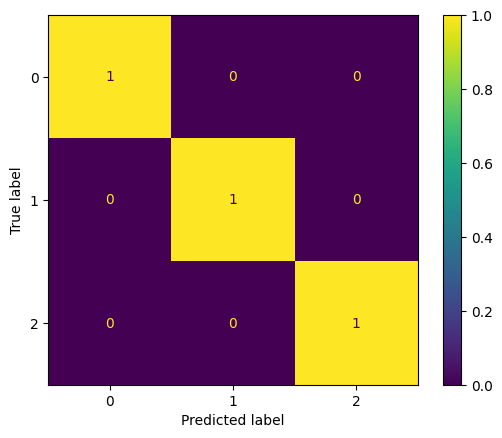

In [50]:
conf_mat = confusion_matrix(y_true= y_poly_test, y_pred= y_poly_pred_test, normalize= "true")

disp = ConfusionMatrixDisplay(conf_mat)
disp.plot()
plt.show()

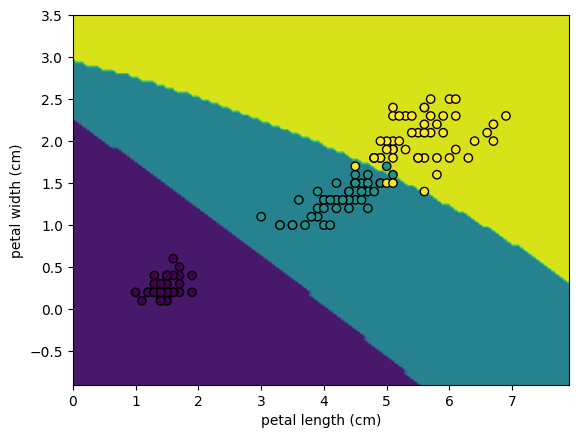

In [68]:
 visual_poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree= 2)),
    ("scaling", StandardScaler()),
    ("logit", LogisticRegression())]
)
a,b = 2,3
X_sub = X[:, [a,b]]
visual_poly_model.fit(X_sub, y_encoded)

display = DecisionBoundaryDisplay.from_estimator(visual_poly_model,
                                                 X_sub,
                                                 xlabel=iris.feature_names[a],
                                                 ylabel=iris.feature_names[b])
display.ax_.scatter(X[:, a], X[:, b], c=y, edgecolors='k')

In [84]:
knn = KNeighborsClassifier(n_neighbors= 10)
knn.fit(X_train, y_train)
y_knn_pred_train = knn.predict(X_train)
y_knn_pred_test = knn.predict(X_test)
print(classification_report(y_test, y_knn_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



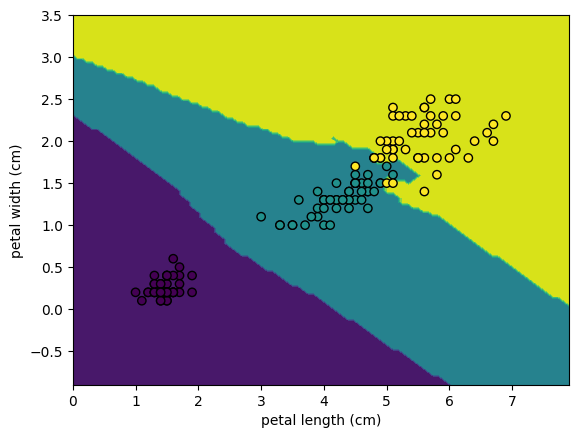

In [76]:
visual_knn_model = Pipeline([
    ("scaling", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors= 5))
])

a,b = 2,3
X_sub = X[:, [a,b]]
visual_knn_model.fit(X_sub, y_encoded)

display = DecisionBoundaryDisplay.from_estimator(visual_knn_model,
                                                 X_sub,
                                                 xlabel=iris.feature_names[a],
                                                 ylabel=iris.feature_names[b])
display.ax_.scatter(X[:, a], X[:, b], c=y, edgecolors='k')